<a href="https://colab.research.google.com/github/bhaviii123/Air_Passenger_Forecasting_ML_vs_DL.ipynb/blob/main/Deep_Horizon_A_Comparative_Deep_Learning_Framework_for_Recursive_COVID_19_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1: Data Acquisition & Cleaning

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten

# Load Data
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df_raw = pd.read_csv(url)

# Country Filter & Daily Conversion
target_country = 'US'
df_country = df_raw[df_raw['Country/Region'] == target_country]
df_ts = df_country.drop(['Province/State', 'Country/Region', 'Lat', 'Long'], axis=1).sum()
df_ts.index = pd.to_datetime(df_ts.index)

# Data Cleaning: Diff gives daily cases; Clip removes negative reporting errors
df_daily = df_ts.diff().fillna(0).clip(lower=0)
data = df_daily.values.reshape(-1, 1)

# Normalization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

/tmp/ipykernel_382/289235016.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ts.index = pd.to_datetime(df_ts.index)


Section 2: Windowing & Sequence Creation

In [8]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_data)
# Reshape for Deep Learning Models (Samples, Time Steps, Features)
X_all = np.reshape(X_all, (X_all.shape[0], X_all.shape[1], 1))

Section 3: Defining Model Architectures

In [9]:
def get_model(model_type, input_shape):
    model = Sequential()
    if model_type == 'FCNN': # Standard Neural Network
        model.add(Flatten(input_shape=input_shape))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(1))
    elif model_type == 'CNN': # Convolutional (Good for patterns)
        model.add(Conv1D(32, kernel_size=2, activation='relu', input_shape=input_shape))
        model.add(Flatten())
        model.add(Dense(1))
    elif model_type == 'LSTM': # Long Short-Term Memory (Good for memory)
        model.add(LSTM(50, input_shape=input_shape))
        model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    return model

Section 4: Testing & Metrics (The 70/30 vs 60/40 Split)

In [10]:
ratios = [0.70, 0.60]
all_results = []
latest_preds, latest_y_true = None, None

for ratio in ratios:
    split_idx = int(len(X_all) * ratio)
    X_train, X_test = X_all[:split_idx], X_all[split_idx:]
    y_train, y_test = y_all[:split_idx], y_all[split_idx:]

    for name in ['FCNN', 'CNN', 'LSTM']:
        model = get_model(name, (60, 1))
        model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

        preds = model.predict(X_test).flatten()
        y_true = y_test.flatten()

        # Capture LSTM 70/30 for the final chart
        if name == 'LSTM' and ratio == 0.70:
            latest_preds, latest_y_true = preds, y_true

        # Calculations
        rmse = np.sqrt(mean_squared_error(y_true, preds))
        r2 = r2_score(y_true, preds)
        rme = (np.mean(np.abs(y_true - preds)) / np.mean(np.abs(y_true))) * 100
        corr, _ = pearsonr(y_true, preds)

        all_results.append({
            "Ratio": f"{int(ratio*100)}/{int((1-ratio)*100)}",
            "Model": name,
            "RMSE": round(rmse, 4),
            "R2": round(r2, 4),
            "RME (%)": round(rme, 2),
            "Corr": round(corr, 4)
        })

results_df = pd.DataFrame(all_results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
   Ratio Model    RMSE      R2  RME (%)    Corr
0  70/30  FCNN  0.2842  0.6087    53.15  0.8641
1  70/30   CNN  0.3081  0.5403    60.36  0.8800
2  70/30  LSTM  0.4303  0.1030    84.37  0.3904
3  60/40  FCNN  0.8399  0.6523    61.17  0.9153
4  60/40   CNN  0.5842  0.8317    43.84  0.9246
5  60/40  LSTM  0.7369  0.7323    60.18  0.8670


Section 5: Performance Visualization

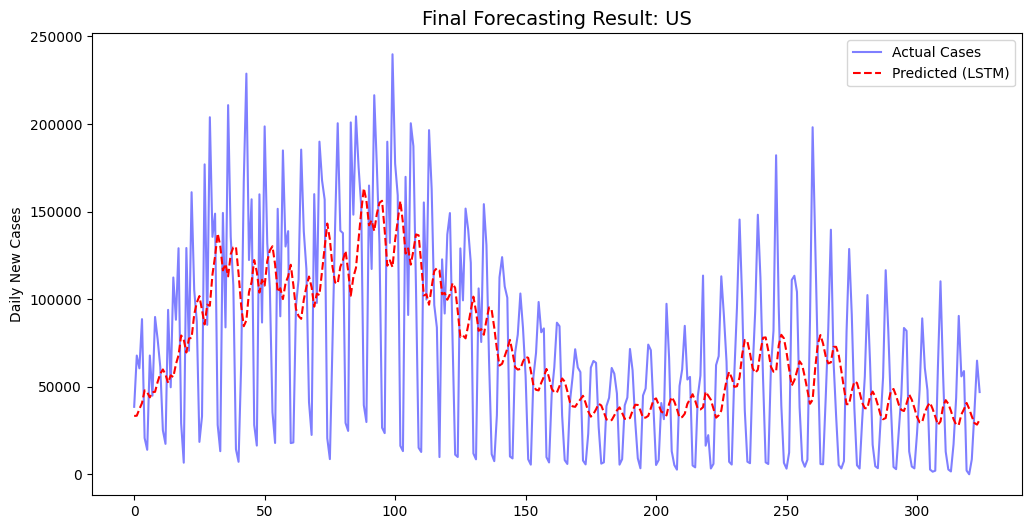

In [11]:
plt.figure(figsize=(12, 6))
# Inverse scaling to show real case numbers
y_real = scaler.inverse_transform(latest_y_true.reshape(-1, 1))
p_real = scaler.inverse_transform(latest_preds.reshape(-1, 1))

plt.plot(y_real, label='Actual Cases', color='blue', alpha=0.5)
plt.plot(p_real, label='Predicted (LSTM)', color='red', linestyle='--')
plt.title(f'Final Forecasting Result: {target_country}', fontsize=14)
plt.ylabel('Daily New Cases')
plt.legend()
plt.show()

Step 1: Data Preparation & Smoothing

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten
from matplotlib.backends.backend_pdf import PdfPages

# 1. Load Live Data
url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df_raw = pd.read_csv(url)

# 2. Filter Country & Process Daily Cases
target_country = 'US'
df_country = df_raw[df_raw['Country/Region'] == target_country]
df_ts = df_country.drop(['Province/State', 'Country/Region', 'Lat', 'Long'], axis=1).sum()
df_daily = df_ts.diff().fillna(0).clip(lower=0)

# 3. Smooth Data (7-Day Moving Average)
df_smoothed = df_daily.rolling(window=7).mean().dropna()
data = df_smoothed.values.reshape(-1, 1)

# 4. Normalize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

Step 2: Training & Benchmarking (Multi-Ratio)
This section trains the FCNN, CNN, and LSTM models on both 70/30 and 60/40 splits.

In [13]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_data)
X_all = np.reshape(X_all, (X_all.shape[0], X_all.shape[1], 1))

def get_model(model_type, input_shape):
    model = Sequential()
    if model_type == 'FCNN':
        model.add(Flatten(input_shape=input_shape))
        model.add(Dense(64, activation='relu'))
        model.add(Dense(1))
    elif model_type == 'CNN':
        model.add(Conv1D(32, kernel_size=2, activation='relu', input_shape=input_shape))
        model.add(Flatten())
        model.add(Dense(1))
    elif model_type == 'LSTM':
        model.add(LSTM(50, input_shape=input_shape))
        model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

ratios = [0.70, 0.60]
all_results = []
final_lstm_model = None

for ratio in ratios:
    split_idx = int(len(X_all) * ratio)
    X_train, X_test = X_all[:split_idx], X_all[split_idx:]
    y_train, y_test = y_all[:split_idx], y_all[split_idx:]

    for name in ['FCNN', 'CNN', 'LSTM']:
        model = get_model(name, (60, 1))
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

        preds = model.predict(X_test).flatten()
        y_true = y_test.flatten()

        if name == 'LSTM' and ratio == 0.70:
            final_lstm_model = model # Save for future forecast

        # Calculate Metrics
        rmse = np.sqrt(mean_squared_error(y_true, preds))
        r2 = r2_score(y_true, preds)
        rme = (np.mean(np.abs(y_true - preds)) / np.mean(np.abs(y_true))) * 100
        corr, _ = pearsonr(y_true, preds)

        all_results.append({"Ratio": f"{int(ratio*100)}/{int((1-ratio)*100)}", "Model": name, "RMSE": round(rmse, 4), "R2": round(r2, 4), "RME (%)": round(rme, 2), "Corr": round(corr, 4)})

results_df = pd.DataFrame(all_results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
   Ratio Model    RMSE      R2  RME (%)    Corr
0  70/30  FCNN  0.1005  0.8606    27.50  0.9637
1  70/30   CNN  0.1056  0.8459    28.05  0.9672
2  70/30  LSTM  0.0643  0.9430    17.17  0.9714
3  60/40  FCNN  0.4618  0.8941    28.25  0.9909
4  60/40   CNN  0.3886  0.9250    27.50  0.9744
5  60/40  LSTM  0.3380  0.9433    18.54  0.9728


Step 3: Recursive Future Forecasting (Next 7 Days)

In [14]:
# Use the last 60 days of known data to start
current_batch = scaled_data[-60:].reshape(1, 60, 1)
future_preds_scaled = []

for _ in range(7):
    next_day = final_lstm_model.predict(current_batch)[0]
    future_preds_scaled.append(next_day)
    # Slide the window: Drop the oldest day, add the predicted day
    current_batch = np.append(current_batch[:, 1:, :], next_day.reshape(1, 1, 1), axis=1)

# Inverse transform to real case numbers
future_cases = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1))

print("\n--- 7-DAY FUTURE PREDICTIONS ---")
for day, cases in enumerate(future_cases, 1):
    print(f"Day {day}: {int(cases[0])} forecasted cases")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

--- 7-DAY FUTURE PREDICTIONS ---
Day 1: 36165 forecasted cases
Day 2: 35935 forecasted cases
Day 3: 35841 forecasted cases
Day 4: 35843 forecasted cases
Day 5: 35914 forecasted cases
Day 6: 36030 forecasted cases
Day 7: 36178 forecasted cases


Step 4: Final Report Export (PDF)

In [15]:
# 1. Create the Performance Plot
fig, ax = plt.subplots(figsize=(10, 5))
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
p_test_real = scaler.inverse_transform(preds.reshape(-1, 1))
ax.plot(y_test_real, label='Actual', alpha=0.6)
ax.plot(p_test_real, label='Predicted', linestyle='--')
ax.set_title(f"COVID-19 Model Performance: {target_country}")
ax.legend()

# 2. Save Everything to PDF
with PdfPages('Internship_Report.pdf') as pdf:
    pdf.savefig(fig) # Save the plot
    plt.close()

print("\nSuccess! Internship_Report.pdf has been generated.")


Success! Internship_Report.pdf has been generated.
